### Chưa resampling:

In [1]:
import json
from collections import Counter

file_path = "outputs/sampled_method1.jsonl"

label_counter = Counter()
first_keys = None

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        obj = json.loads(line)

        if first_keys is None:
            first_keys = list(obj.keys())

        label = None
        for key in ["class", "label", "labels", "category", "target"]:
            if key in obj:
                label = obj[key]
                break

        if label is None:
            continue

        if isinstance(label, list):
            label_counter.update(label)
        else:
            label_counter[str(label)] += 1

print("Số lượng mẫu theo từng class:")
for cls, cnt in label_counter.most_common():
    print(f"{cls}: {cnt}")

if not label_counter:
    print("\nKhông tìm thấy cột nhãn phù hợp.")
    print("Các key của record đầu tiên:", first_keys)

Số lượng mẫu theo từng class:
1: 408708
0: 408708


## EDA toàn diện cho sampled_method1

Mục tiêu:
- Thống kê cơ bản: schema, phân phối nhãn, missing/null.
- Thống kê nâng cao: độ dài text theo class, duplicate, quality flags.
- Trực quan hóa: biểu đồ nhãn + phân phối độ dài.
- Kết luận hành động trước huấn luyện.

In [2]:
import json
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 160)

CONFIG = {
    "file_path": Path("outputs/sampled_method1.jsonl"),
    "candidate_text_keys": ["text", "sentence", "content", "body"],
    "candidate_label_keys": ["label", "class", "labels", "category", "target"],
    "short_text_threshold": 10,
    "long_text_threshold": 500,
}

print("Đường dẫn dữ liệu:", CONFIG["file_path"])
print("Tồn tại file:", CONFIG["file_path"].exists())

Đường dẫn dữ liệu: outputs/sampled_method1.jsonl
Tồn tại file: True


In [3]:
records = []
parse_errors = 0
empty_lines = 0
first_keys = None

with CONFIG["file_path"].open("r", encoding="utf-8") as f:
    for line_idx, line in enumerate(f, start=1):
        if not line.strip():
            empty_lines += 1
            continue
        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            parse_errors += 1
            continue

        if first_keys is None:
            first_keys = list(obj.keys())

        text_key = next((k for k in CONFIG["candidate_text_keys"] if k in obj), None)
        label_key = next((k for k in CONFIG["candidate_label_keys"] if k in obj), None)

        text = obj.get(text_key) if text_key else None
        label = obj.get(label_key) if label_key else None

        records.append(
            {
                "line_idx": line_idx,
                "text_key": text_key,
                "label_key": label_key,
                "text": text,
                "label": label,
                "raw": obj,
            }
        )

print("Tong so dong hop le:", len(records))
print("Dong rong:", empty_lines)
print("Loi parse JSON:", parse_errors)
print("Key cua record dau tien:", first_keys)

df = pd.DataFrame(records)
print("\nSchema trich xuat:")
print(df[["text_key", "label_key"]].nunique().rename("n_unique"))

df.head(3)

Tong so dong hop le: 817416
Dong rong: 0
Loi parse JSON: 0
Key cua record dau tien: ['text', 'label']

Schema trich xuat:
text_key     1
label_key    1
Name: n_unique, dtype: int64


,line_idx,text_key,label_key,text,label,raw
0,1,text,label,Danh sách cầu thủ đã được ấn định vào ngày 24 tháng 7 năm 2024.,1,"{'text': ' Danh sách cầu thủ đã được ấn định vào ngày 24 tháng 7 năm 2024.', 'label': 1}"
1,2,text,label,"Huong T. D. Nguyen tại đại học Ohio cho rằng Phùng Thị Xuân Khải và Phùng Gia Lộc là ""hai tác giả nổi tiếng về sự nghiệp bị ảnh hưởng bất lợi do thuật lại ...",1,"{'text': ' Huong T. D. Nguyen tại đại học Ohio cho rằng Phùng Thị Xuân Khải và Phùng Gia Lộc là ""hai tác giả nổi tiếng về sự nghiệp bị ảnh hưởng bất lợi do ..."
2,3,text,label,Hầu hết những người Đức định cư đã nhập cư từ Ba Lan Lập hiến.,1,"{'text': ' Hầu hết những người Đức định cư đã nhập cư từ Ba Lan Lập hiến.', 'label': 1}"


In [4]:
# Chuẩn hóa text/label để thống kê

def normalize_label(x):
    if isinstance(x, bool):
        return int(x)
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float) and x.is_integer():
        return int(x)
    if isinstance(x, str):
        s = x.strip().lower()
        if s in {"0", "false", "neg", "negative", "no"}:
            return 0
        if s in {"1", "true", "pos", "positive", "yes"}:
            return 1
        return s
    return x


def clean_text(x):
    if x is None:
        return ""
    if not isinstance(x, str):
        x = str(x)
    return re.sub(r"\s+", " ", x).strip()


df["text_clean"] = df["text"].map(clean_text)
df["label_norm"] = df["label"].map(normalize_label)

df["is_text_missing"] = df["text"].isna() | (df["text_clean"] == "")
df["is_label_missing"] = df["label"].isna()

label_dist = df["label_norm"].value_counts(dropna=False).sort_index()

print("Tong record:", len(df))
print("Text missing/rong:", int(df["is_text_missing"].sum()))
print("Label missing:", int(df["is_label_missing"].sum()))
print("\nPhan phoi label:")
print(label_dist)

if 0 in label_dist.index and 1 in label_dist.index:
    ratio = label_dist[1] / max(label_dist[0], 1)
    print(f"\nTi le class 1 / class 0: {ratio:.4f}")

Tong record: 817416
Text missing/rong: 9
Label missing: 0

Phan phoi label:
label_norm
0    408708
1    408708
Name: count, dtype: int64

Ti le class 1 / class 0: 1.0000


In [5]:
# Thống kê độ dài text
valid_text_df = df.loc[~df["is_text_missing"]].copy()
valid_text_df["char_len"] = valid_text_df["text_clean"].str.len()
valid_text_df["word_len"] = valid_text_df["text_clean"].str.split().map(len)


def describe_series(s):
    return pd.Series(
        {
            "count": int(s.count()),
            "min": float(s.min()),
            "p25": float(s.quantile(0.25)),
            "median": float(s.median()),
            "mean": float(s.mean()),
            "p75": float(s.quantile(0.75)),
            "p95": float(s.quantile(0.95)),
            "max": float(s.max()),
            "std": float(s.std(ddof=0)),
        }
    )

print("Thong ke do dai (ky tu):")
display(describe_series(valid_text_df["char_len"]).to_frame("char_len").T)

print("Thong ke do dai (tu):")
display(describe_series(valid_text_df["word_len"]).to_frame("word_len").T)

print("Thong ke theo class (ky tu):")
by_class_char = valid_text_df.groupby("label_norm")["char_len"].apply(describe_series)
by_class_char = by_class_char.unstack(1)
display(by_class_char)

Thong ke do dai (ky tu):


,count,min,p25,median,mean,p75,p95,max,std
char_len,817407.0,1.0,74.0,117.0,130.655812,170.0,276.0,33608.0,96.712072


Thong ke do dai (tu):


,count,min,p25,median,mean,p75,p95,max,std
word_len,817407.0,1.0,15.0,25.0,27.465476,36.0,59.0,4572.0,19.520565


Thong ke theo class (ky tu):


,count,min,p25,median,mean,p75,p95,max,std
label_norm,,,,,,,,,
0,408708.0,1.0,71.0,111.0,124.029750,161.0,260.0,13099.0,87.751015
1,408699.0,1.0,77.0,123.0,137.282019,179.0,291.0,33608.0,104.491307


In [6]:
# Kiểm tra chất lượng dữ liệu nâng cao
markup_pattern = re.compile(r"<[^>]+>")

valid_text_df["has_markup"] = valid_text_df["text_clean"].str.contains(markup_pattern)
valid_text_df["is_short"] = valid_text_df["char_len"] < CONFIG["short_text_threshold"]
valid_text_df["is_long"] = valid_text_df["char_len"] > CONFIG["long_text_threshold"]

text_dup_count = int(valid_text_df.duplicated(subset=["text_clean"]).sum())
pair_dup_count = int(valid_text_df.duplicated(subset=["text_clean", "label_norm"]).sum())

summary_quality = pd.Series(
    {
        "n_records_valid_text": int(len(valid_text_df)),
        "n_duplicate_text": text_dup_count,
        "n_duplicate_text_label": pair_dup_count,
        "n_short_text": int(valid_text_df["is_short"].sum()),
        "n_long_text": int(valid_text_df["is_long"].sum()),
        "n_has_markup": int(valid_text_df["has_markup"].sum()),
    }
)
summary_quality["pct_duplicate_text"] = summary_quality["n_duplicate_text"] / max(summary_quality["n_records_valid_text"], 1)
summary_quality["pct_has_markup"] = summary_quality["n_has_markup"] / max(summary_quality["n_records_valid_text"], 1)

print("Tong hop chat luong du lieu:")
display(summary_quality.to_frame("value"))

print("\nTop 10 mau co markup (neu co):")
display(valid_text_df.loc[valid_text_df["has_markup"], ["label_norm", "char_len", "text_clean"]].head(10))

print("\nTop 10 mau rat ngan:")
display(valid_text_df.nsmallest(10, "char_len")[["label_norm", "char_len", "text_clean"]])

print("\nTop 10 mau rat dai:")
display(valid_text_df.nlargest(10, "char_len")[["label_norm", "char_len", "text_clean"]])

Tong hop chat luong du lieu:


,value
n_records_valid_text,817407.000000
n_duplicate_text,309.000000
n_duplicate_text_label,123.000000
n_short_text,5773.000000
n_long_text,2673.000000
n_has_markup,111357.000000
pct_duplicate_text,0.000378
pct_has_markup,0.136232



Top 10 mau co markup (neu co):


,label_norm,char_len,text_clean
4,1,29,"<ref name=""Sal"">[https://www."
8,1,142,"Men có truyền thống được sử dụng để trang trí các vật thể quý giá,<ref>Mayer, Ralph,The Artist's Handbook of Materials and Techniques, 3rd ed."
12,1,88,"Thì passé simple được sử dụng để thể hiện:<ref name=""Lang"">Lang, M. and Perez I. (2004)."
15,1,22,"<ref>Hartley, Lindsey."
22,1,33,v=xolsn9M4FXU 香港樂壇戰國時代之張學友]</ref>
25,1,290,":Giả thuyết về vách Néel sinh ra sau giả thuyết về vách Bloch, và được đặt tên theo nhà vật lý học người Pháp Louis Eugène Félix Néel <ref>A. Hubert, R. Sch..."
35,1,328,"Trong khi đó, chính phủ Nhật Bản cho hành động của Nga công nhận nền độc lập của bán đảo Krym là vi phạm chủ quyền và sự vẹn toàn lãnh thổ của Ukraina, và p..."
38,1,53,"<ref>Hogan, C. Michael (2008) [http://globaltwitcher."
40,1,270,"Tần Cối lệnh cho tên đao phủ đem Nhạc Phi đi treo cổ ở đình Phong Ba (""Phong Ba"" nghĩa là ""Gió Bão"", tức là đình ""Gió Bão"") thuộc Đại lý tự Lâm An, khi đó N..."
41,1,164,"nz""></ref> Đây là giải đấu thứ ba của FIFA được tổ chức tại quốc gia này, sau Giải vô địch bóng đá U-17 thế giới 1999 và Giải vô địch bóng đá nữ U-17 thế gi..."



Top 10 mau rat ngan:


,label_norm,char_len,text_clean
66558,1,1,″
82481,1,1,4
166418,1,1,’
183517,1,1,”
185883,0,1,–
202780,1,1,""""
210725,1,1,8
222852,1,1,“
227831,1,1,﻿
237474,1,1,。



Top 10 mau rat dai:


,label_norm,char_len,text_clean
56418,1,33608,Các loài trong chi này gồm: * Megachile abacula * Megachile abdominalis * Megachile abessinica * Megachile abluta * Megachile abnegatula * Megachile abnormi...
382779,0,13099,:* Isodontia albata :* Isodontia alvarengai :* Isodontia apicalis :* Isodontia apicata :* Isodontia aurifrons :* Isodontia auripes :* Isodontia auripygata :...
693224,0,8734,Thông giám kỷ sự bản mạt được chia thành 239 tiêu đề như sau: #Ba nhà chia Tấn (三家分晋) #Tần thôn tính sáu nước (秦併六國) #Hào kiệt diệt Tần (豪傑亡秦) #Cao Đế diệt ...
810853,0,8182,Tetragnatha * Tetragnatha acuta * Tetragnatha aenea * Tetragnatha aetherea * Tetragnatha albida * Tetragnatha americana * Tetragnatha amoena * Tetragnatha a...
765372,1,8174,"Đội thời gian vàng của Trung tâm báo án 112 * Son Eun-seo vai Park Eun Soo, chuyên viên ngôn ngữ * Kim Woo-seok vai Jin Seo Yool, hacker thiên tài, chuyên v..."
460222,0,8064,Xysticus * Xysticus abditus * Xysticus abramovi * Xysticus acerbus ** Xysticus acerbus obscurior * Xysticus acquiescens * Xysticus advectus * Xysticus adzha...
207041,1,6590,"Chi Aegiphila gồm các loài: #Aegiphila aculeifera - Colombia #Aegiphila alba - Colombia, Ecuador, Peru #Aegiphila anomala - Colombia, Panama, Costa Rica #Ae..."
730473,0,5665,"1982 *Quán quân cuộc thi ca hát Tân Tú lần thứ nhất (với ca khúc ""Mùa Của Gió"") 1983 *Giải thưởng tại tiết mục âm nhạc Tokyo - Á Châu lần thứ 12 *Giải thưởn..."
768121,0,5181,Dysdera * Dysdera aciculata * Dysdera aculeata * Dysdera adriatica * Dysdera affinis * Dysdera afghana * Dysdera alegranzaensis * Dysdera alentejana * Dysde...
83285,0,4874,Cheiracanthium * Cheiracanthium abbreviatum * Cheiracanthium aculeatum * Cheiracanthium aden * Cheiracanthium adjacens * Cheiracanthium africanum * Cheiraca...


In [7]:
# Bucket độ dài và so sánh theo class
bins = [0, 50, 100, 150, 200, 300, 500, 10_000]
labels = ["<=50", "51-100", "101-150", "151-200", "201-300", "301-500", ">500"]
valid_text_df["length_bucket"] = pd.cut(valid_text_df["char_len"], bins=bins, labels=labels, include_lowest=True)

bucket_table = (
    valid_text_df.groupby(["label_norm", "length_bucket"], observed=False)
    .size()
    .unstack(0, fill_value=0)
)

bucket_ratio = bucket_table.div(bucket_table.sum(axis=1).replace(0, np.nan), axis=0)

print("Bang tan suat bucket do dai theo class:")
display(bucket_table)

print("\nTi le class trong tung bucket:")
display((bucket_ratio * 100).round(2))

Bang tan suat bucket do dai theo class:


label_norm,0,1
length_bucket,,
<=50,56698,55323
51-100,121096,97519
101-150,110667,107073
151-200,65414,73215
201-300,44235,57750
301-500,9574,16170
>500,1023,1648



Ti le class trong tung bucket:


label_norm,0,1
length_bucket,,
<=50,50.61,49.39
51-100,55.39,44.61
101-150,50.83,49.17
151-200,47.19,52.81
201-300,43.37,56.63
301-500,37.19,62.81
>500,38.30,61.70


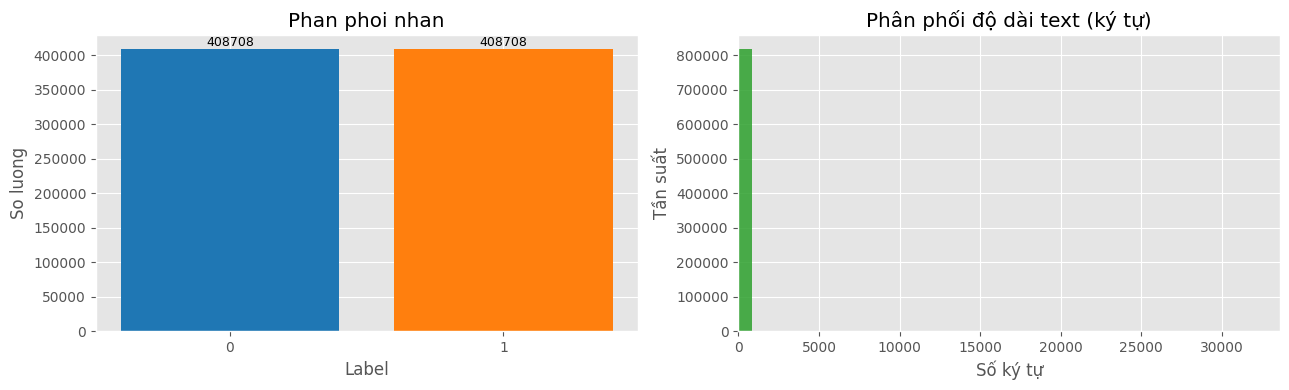

In [13]:
# Trực quan hóa: phân phối nhãn và độ dài
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_dist_plot = df["label_norm"].value_counts().sort_index()
axes[0].bar(label_dist_plot.index.astype(str), label_dist_plot.values, color=["#1f77b4", "#ff7f0e", "#2ca02c"][: len(label_dist_plot)])
axes[0].set_title("Phan phoi nhan")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("So luong")

for i, v in enumerate(label_dist_plot.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom", fontsize=9)

axes[1].hist(valid_text_df["char_len"], bins=40, color="#2ca02c", alpha=0.85)
axes[1].set_title("Phân phối độ dài text (ký tự)")
axes[1].set_xlabel("Số ký tự")
axes[1].set_ylabel("Tần suất")
axes[1].set_xlim(0, valid_text_df["char_len"].max())

plt.tight_layout()
plt.show()

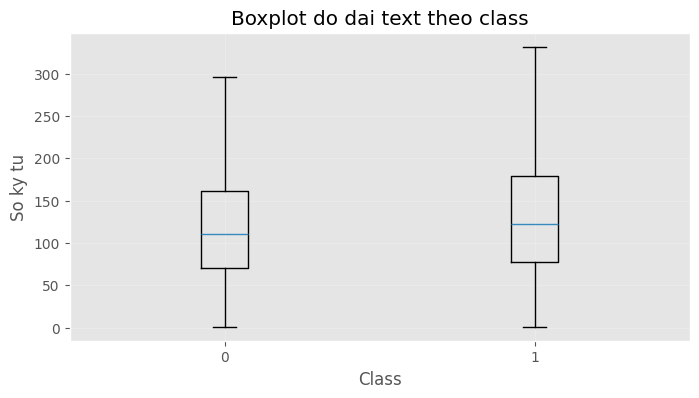

In [9]:
# Trực quan hóa: boxplot độ dài theo class
classes = sorted(valid_text_df["label_norm"].dropna().unique(), key=lambda x: str(x))
box_data = [valid_text_df.loc[valid_text_df["label_norm"] == c, "char_len"].values for c in classes]

plt.figure(figsize=(8, 4))
plt.boxplot(box_data, tick_labels=[str(c) for c in classes], showfliers=False)
plt.title("Boxplot do dai text theo class")
plt.xlabel("Class")
plt.ylabel("So ky tu")
plt.grid(alpha=0.2)
plt.show()

In [10]:
# Tong ket EDA va khuyen nghi
summary = {
    "records_total": int(len(df)),
    "records_valid_text": int(len(valid_text_df)),
    "parse_errors": int(parse_errors),
    "empty_lines": int(empty_lines),
    "label_distribution": {str(k): int(v) for k, v in label_dist.to_dict().items()},
    "char_len_mean": float(valid_text_df["char_len"].mean()) if len(valid_text_df) else None,
    "char_len_median": float(valid_text_df["char_len"].median()) if len(valid_text_df) else None,
    "duplicate_text_pct": float(summary_quality["pct_duplicate_text"]),
    "markup_pct": float(summary_quality["pct_has_markup"]),
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ["value"]
print("Bang tong ket:")
display(summary_df)

print("\nKhuyen nghi truoc train:")
recs = []
if summary_quality["n_has_markup"] > 0:
    recs.append("- Co markup con sot: nen clean regex truoc train de tranh leakage.")
if summary_quality["n_duplicate_text"] > 0:
    recs.append("- Co duplicate text: can nhac train tren ban dedup de giam overfit.")
if summary_quality["n_short_text"] > 0:
    recs.append(f"- Co text qua ngan (< {CONFIG['short_text_threshold']}): can nhac loc bo.")
if 0 in label_dist.index and 1 in label_dist.index:
    ratio = label_dist[1] / max(label_dist[0], 1)
    if ratio < 0.8 or ratio > 1.25:
        recs.append("- Label lech dang ke: can nhac weighting hoac resampling khi train.")

if not recs:
    recs.append("- Du lieu nhin chung on cho train baseline.")

for r in recs:
    print(r)

Bang tong ket:


,value
records_total,817416
records_valid_text,817407
parse_errors,0
empty_lines,0
label_distribution,"{'0': 408708, '1': 408708}"
char_len_mean,130.655812
char_len_median,117.0
duplicate_text_pct,0.000378
markup_pct,0.136232



Khuyen nghi truoc train:
- Co markup con sot: nen clean regex truoc train de tranh leakage.
- Co duplicate text: can nhac train tren ban dedup de giam overfit.
- Co text qua ngan (< 10): can nhac loc bo.
